# RAG sistem za pretragu naučnih radova

Notebook implementira RAG (Retrieval-Augmented Generation) sistem koji za zadatu naučnu tvrdnju pronalazi relevantne delove radova iz BEIR SciFact korpusa i generiše odgovor zasnovan na sadržaju dokumenata, umesto na opštem znanju jezičkog modela. Sistem se gradi i poredi kroz tri varijante: baseline jezički model (FLAN-T5), baseline sa pretreniranim embedding modelom (all-MiniLM-L6-v2) za pretragu, i baseline sa fine-tunovanim embedding modelom. Kvalitet pretrage se ocenjuje pomoću NDCG@10, Recall@10 i MRR@10 metrika.

# Struktura notebook-a
## 1. Učitavanje *dataset*-a
## 2. Podela na skupove
## 3. *Rolling window* metoda
## 4. Izgradnja FAISS vektorskog indeksa, sa baseline
## 5. Evaluacija pretreniranog modela i baseline metrike
## 6. Fine-tuning embedding modela
### 6.1. Ispis top 5 metrika
### 6.2. Druga pretraga HPO
### 6.3. Ispis top 5 metrika
## 7. Treniranje modela sa najboljim HPO
### 7.1.  Evaluacija fine-tunovanog modela
## 8. Ponovna izgradnja FAISS vektorskog indeksa sa fine-tunovanim modelom
## 9. RAG sistem
### 9.1. Gold tvrdnje
### 9.2. Poređenje pristupa


# Instaliranje potrebnih zavisnosti i povezivanje sa drive-om

In [ ]:
!pip install beir sentence-transformers transformers datasets faiss-cpu torch
!pip install tqdm
!pip install optuna

import os
import io
import gc
import copy
import json
import random
import pathlib
import textwrap
import zipfile
import tarfile
import urllib.request

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import faiss
import optuna

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from sentence_transformers import SentenceTransformer, InputExample, losses, util
from sentence_transformers.evaluation import InformationRetrievalEvaluator, SentenceEvaluator
from sentence_transformers.training_args import BatchSamplers

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

from beir.datasets.data_loader import GenericDataLoader
from beir.retrieval.evaluation import EvaluateRetrieval

from google.colab import files, drive

llm_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-xl")
llm_model = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-xl",
    torch_dtype=torch.float16,
    device_map="auto"
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.8 MB/s eta 0:00:00


/tmp/ipykernel_25337/3463268430.py:28: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses, util
/tmp/ipykernel_25337/3463268430.py:29: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import InformationRetrievalEvaluator, SentenceEvaluator
/tmp/ipykernel_25337/3463268430.py:30: DeprecationWarning: Importing from 'sentence_transformers.training_args' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.training_args' instead.
  from sentence_transformers.training_args import BatchSamplers


config.json:   0%|          | 0.00/1.44k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/53.0k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
#Mountovanje Drive-a i sve putanje na jednom mestu
#Podrazumevano vode na Google Drive korisnika ciji je Colab
#Promeniti po potrebi, ako se rezultati cuvaju negde drugde
drive.mount("/content/drive")

#prva HPO pretraga
HPO1_BASE_DIR = "/content/drive/MyDrive/optuna_trials_hpo"
#druga HPO pretraga
HPO2_BASE_DIR = "/content/drive/MyDrive/optuna_trials_hpo_druga"

#finalni model i grafik los-a
FINETUNED_MODEL_DIR = "/content/drive/MyDrive/finetuned_model"
LOSS_PLOT_PATH = "/content/drive/MyDrive/loss_po_epohi.png"


Mounted at /content/drive


# 1. Učitavanje *dataset*-a
Koristi se *BEIR SciFact*. To je stručno anotiran korpus namenjen verifikaciji naučnih tvrdnji.  
Konkretno, baza se sastoji od tri komponente:
1. Korpus koji sadrži naslove i tekstove dokumenata
2. Skup upita u vidu naučnih tvrdnji
3. Oznaka relevantnosti koji definiše koji dokumenti podržavaju ili opovrgavaju koje tvrdnje (SUPPORT ukoliko dokument podržava tvrdnju, CONTRADICT ukoliko dokument opovrgava tvrdnju, NOINFO ukoliko dokument nije relevantan)

Dakle, radi se o bazi u kojoj svaki dokument predstavlja kratak naučni apstrakt, a svaki upit predstavlja naučnu tvrdnju koju treba proveriti pronalaženjem relevantnih dokaza u korpusu.
Dužina tekstova, upita, primeri teksta i upita i ostale statističke vrednosti su dostupne u izvršenoj ćeliji.

  0%|          | 0/5183 [00:00<?, ?it/s]

  0%|          | 0/5183 [00:00<?, ?it/s]

Korpus: 5183
Train upiti: 809, test upiti: 300
Train parova: 919, test parova: 339
Nedostajuci u korpusu, train: 0, test: 0
Upiti koji se poklapaju train/test: 0
Duplikati u korpusu: 0
Korpus duzina, min: 33, max: 1541, avg: 214.6
Train upiti duzina, min: 3, max: 39, avg: 12.3
Test upiti duzina,  min: 4, max: 29, avg: 12.5


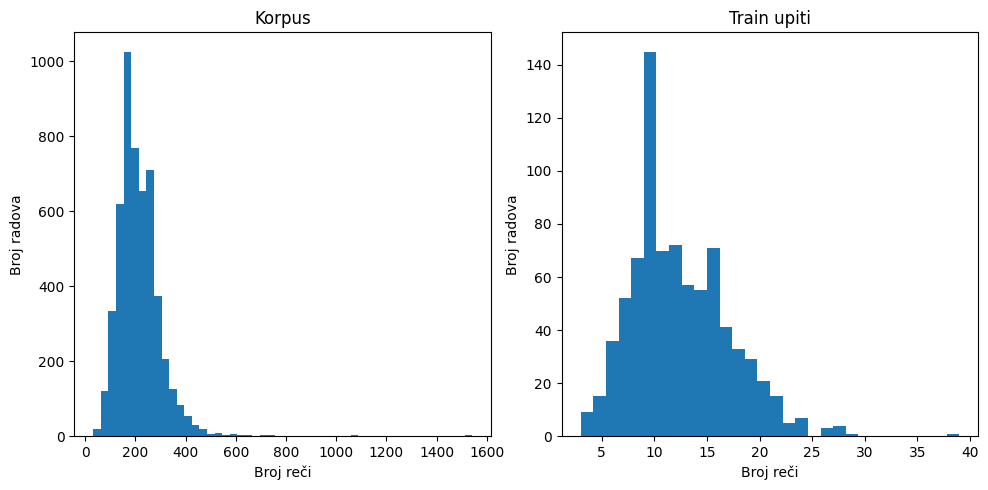

Primer upita (ID: 1): 0-dimensional biomaterials show inductive properties.
Primer dokumenta (ID: 4983):
Naslov: Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.
Tekst: Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities. A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7). To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term. In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decrease

In [ ]:
dataset = "scifact"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset}.zip"
out_dir = os.path.join(pathlib.Path(".").absolute(), "datasets")
os.makedirs(out_dir, exist_ok=True)
r = requests.get(url)
zipfile.ZipFile(io.BytesIO(r.content)).extractall(out_dir)
data_path = os.path.join(out_dir, dataset)

corpus, queries_train, qrels_train = GenericDataLoader(data_folder=data_path).load(split="train")
corpus, queries_test, qrels_test = GenericDataLoader(data_folder=data_path).load(split="test")

print(f"Korpus: {len(corpus)}")
print(f"Train upiti: {len(queries_train)}, test upiti: {len(queries_test)}")

train_pairs = sum(len(docs) for docs in qrels_train.values())
test_pairs = sum(len(docs) for docs in qrels_test.values())
print(f"Train parova: {train_pairs}, test parova: {test_pairs}")

corpus_ids = set(corpus.keys())
missing_train = set(doc_id for docs in qrels_train.values() for doc_id in docs) - corpus_ids
missing_test = set(doc_id for docs in qrels_test.values() for doc_id in docs) - corpus_ids
print(f"Nedostajuci u korpusu, train: {len(missing_train)}, test: {len(missing_test)}")

overlap = set(queries_train.keys()) & set(queries_test.keys())
print(f"Upiti koji se poklapaju train/test: {len(overlap)}")

corpus_texts = [v["title"] + " " + v["text"] for v in corpus.values()]
print(f"Duplikati u korpusu: {len(corpus_texts) - len(set(corpus_texts))}")

corpus_lens = [len((v["title"] + " " + v["text"]).split()) for v in corpus.values()]
train_lens = [len(q.split()) for q in queries_train.values()]
test_lens = [len(q.split()) for q in queries_test.values()]

print(f"Korpus duzina, min: {min(corpus_lens)}, max: {max(corpus_lens)}, avg: {sum(corpus_lens)/len(corpus_lens):.1f}")
print(f"Train upiti duzina, min: {min(train_lens)}, max: {max(train_lens)}, avg: {sum(train_lens)/len(train_lens):.1f}")
print(f"Test upiti duzina,  min: {min(test_lens)}, max: {max(test_lens)}, avg: {sum(test_lens)/len(test_lens):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].hist(corpus_lens, bins=50)
axes[0].set_title("Korpus")
axes[0].set_xlabel("Broj reči")
axes[0].set_ylabel("Broj radova")

axes[1].hist(train_lens, bins=30)
axes[1].set_title("Train upiti")
axes[1].set_xlabel("Broj reči")
axes[1].set_ylabel("Broj radova")


plt.tight_layout()
plt.savefig("korpus.png", dpi=150, bbox_inches='tight')
plt.show()


primer_qid = list(queries_test.keys())[0]
print(f"Primer upita (ID: {primer_qid}): {queries_test[primer_qid]}")

primer_doc_id = list(corpus.keys())[0]
primer_doc = corpus[primer_doc_id]
print(f"Primer dokumenta (ID: {primer_doc_id}):\nNaslov: {primer_doc['title']}\nTekst: {primer_doc['text']}")

# 2. Podela na skupove
*Dataset* sadrži podelu na trening i test, ali ne sadrži validacioni skup, koji će kasnije biti potreban prilikom odabira hiperparametara.
Zato se u ovom koraku deo trening skupa odvaja kao validacioni.

Podela skupa rađena je na nivou upita, a ne na nivou pojedinačnih upit-dokument parova, kako bi se sprečilo curenje informacija između trening i validacionog skupa (data leak).

Razlog je što jedan upit (tvrdnja) može biti povezan sa više relevantnih dokumenata, pa bi deljenje po parovima dovelo do situacije da se isti upit nađe istovremeno i u trening i u validacionom skupu, samo sa različitim pridruženim dokumentima

Stanje sa skupovima je sledeće:
1.   Trening parova: 827
2.   Validacionih parova: 92
3.   Test parova: 339

In [ ]:
#podela po upitima (ne po parovima) da isti upit ne bi bio i u train i u val
qids = list(qrels_train.keys())
qids_train, qids_val = train_test_split(qids, test_size=0.1, random_state=44)

qrels_train_final = {qid: qrels_train[qid] for qid in qids_train}
qrels_val = {qid: qrels_train[qid] for qid in qids_val}

queries_train_final = {qid: queries_train[qid] for qid in qids_train}
queries_val = {qid: queries_train[qid] for qid in qids_val}

train_qids = set(qrels_train_final)
val_qids = set(qrels_val)
test_qids = set(qrels_test)

print("train presek val:", len(train_qids & val_qids))
print("train presek test:", len(train_qids & test_qids))
print("val presek test:", len(val_qids & test_qids))

print("train upita:", len(queries_train_final))
print("val upita:", len(queries_val))
print("train parova:", sum(len(d) for d in qrels_train_final.values()))
print("val parova:", sum(len(d) for d in qrels_val.values()))
print("test parova:", sum(len(d) for d in qrels_test.values()))

train presek val: 0
train presek test: 0
val presek test: 0
train upita: 728
val upita: 81
train parova: 827
val parova: 92
test parova: 339


# 3. *Rolling window* metoda
Problem koji  postoji je da je ograničenje modela 256 tokena na ulazu, a ranija analiza je pokazala da je prosečan broj reči 215. To je približno 280 tokena, s tim da je s obzirom na prirodu dataseta taj broj vrlo verovatno i veći.

To znači da će svi tokeni koji premaše 256 biti odsečeni, odnosno gubi se deo teksta. Jasno je da zbog toga model ne raspolaže celim tekstom, a moguće je da se bitna informacija nalazi baš na kraju. Zato se koristi metoda rolling window.


Definiše se veličina prozora (broj tokena u svakom prozoru, window), kao i korak pomeranja prozora (stride).
Ovi parametri određeni su empirijski (*window = 190,  stride = 100*), na osnovu karakteristika korpusa i ograničenja embedding modela.

Kratki dokumenti koji staju u jedan prozor se ne seku.

Svaki prozor dobija ID u formatu originalni_id#pozicija, npr. 1234#0, 1234#100, 1234#200, tako da je poznato kom dokumentu prozor pripada.

Postupak obezbeđuje da, za radove veće od 256 tokena,  postoji više vektora koji ga opisuju. Originalni broj dokumenata je 5183, a nakon primene ove metode taj broj je 15261.


In [ ]:
def print_wrapped(text, width=100):
    print(textwrap.fill(text, width=width))

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2") #tokenizer specifcan za model, to je njegov recnik

window = 190
stride = 100

chunked_corpus = {}
for doc_id, doc in corpus.items():
    text = doc["title"] + " " + doc["text"]
    tokens = tokenizer.encode(text, add_special_tokens=False)

    if len(tokens) <= window:
        chunked_corpus[doc_id] = {"text": tokenizer.decode(tokens)}
        continue

    i = 0
    while i < len(tokens):
        chunk_tokens = tokens[i:i + window]
        chunk_id = f"{doc_id}#{i}"
        chunked_corpus[chunk_id] = {"text": tokenizer.decode(chunk_tokens)}
        if i + window >= len(tokens):
            break
        i += stride

for doc_id in list(corpus.keys())[:4]:
    doc_text = corpus[doc_id]["title"] + " " + corpus[doc_id]["text"]
    doc_tokens = tokenizer.encode(doc_text, add_special_tokens=False, truncation=False, max_length=None)
    print(f"\n-originalni tekst: {doc_id} ({len(doc_tokens)} tokena) ")
    print_wrapped(doc_text)
    print()

    #ispravan filter: tacno doc_id (kratak doc) ili doc_id#pozicija (chunkovani doc)
    chunks = {
        k: v for k, v in chunked_corpus.items()
        if k == doc_id or k.startswith(f"{doc_id}#")
    }

    print(f"{len(chunks)} chunkova ")
    for chunk_id, chunk in chunks.items():
        chunk_tokens = tokenizer.encode(chunk["text"], add_special_tokens=False)
        words = chunk["text"].split()
        print(f"{chunk_id}: {len(chunk_tokens)} tokena")
        print(f"pocetak: {' '.join(words[:10])}")
        print(f"kraj: {' '.join(words[-10:])}")
        print()

max_tokens = max(
    len(tokenizer.encode(v["text"], add_special_tokens=False))
    for v in chunked_corpus.values()
)
print(f"Maksimalan broj tokena u chunkovima: {max_tokens}")
print(f"Ukupno chunkova: {len(chunked_corpus)}")
print(f"Originalni dokumenti: {len(corpus)}")

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (547 > 512). Running this sequence through the model will result in indexing errors



-originalni tekst: 4983 (450 tokena) 
Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion
tensor magnetic resonance imaging. Alterations of the architecture of cerebral white matter in the
developing human brain can affect cortical development and result in functional disabilities. A line
scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was
applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to
delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and
full-term infants (n = 7). To assess effects of prematurity on cerebral white matter development,
early gestation preterm infants (n = 10) were studied a second time at term. In the central white
matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased
toward term to 1.2 microm2/ms. In the posterior limb of the internal capsule, t

# 4. Izgradnja FAISS vektorskog indeksa, sa baseline

Svaki dokument se najpre seče na prozore (parametrima određenim u prethodnoj ćeliji), koji se zatim embeduju modelom all-MiniLM-L6-v2.

Vektori se normalizuju i dodaju u FAISS indeks koji koristi
Inner Product kao meru sličnosti. Na normalizovanim vektorima
ovo je ekvivalentno kosinusnoj sličnosti.

In [ ]:
chunk_ids_list = list(chunked_corpus.keys())
chunk_texts = [chunked_corpus[cid]["text"] for cid in chunk_ids_list]

model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda" if torch.cuda.is_available() else "cpu")
chunk_embeddings = model.encode(chunk_texts, convert_to_numpy=True,
                                 show_progress_bar=True).astype("float32")

dim = chunk_embeddings.shape[1]
faiss.normalize_L2(chunk_embeddings)
index = faiss.IndexFlatIP(dim)
index.add(chunk_embeddings)


id_map = {i: chunk_id for i, chunk_id in enumerate(chunk_ids_list)}

faiss.write_index(index, "faiss_index.bin")
with open("id_map.json", "w") as f:
    json.dump(id_map, f)

print(f"u indeksu: {index.ntotal} vektora (chunkova)")
print(f"originalni dokumenti: {len(corpus)}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/477 [00:00<?, ?it/s]

u indeksu: 15261 vektora (chunkova)
originalni dokumenti: 5183


# 5. Evaluacija pretreniranog modela i baseline metrike

Nakon izgradnje FAISS indeksa sa pretreniranim modelom, meri se kvalitet
retrievala na test skupu. Svaki test upit se embeduje istim modelom,
pretražuje se indeks i uzima se top 10 najsličnijih dokumenata.

Rezultati se porede sa qrels_test oznakama relevantnosti koristeći tri metrike:

- **NDCG@10** (Normalized Discounted Cumulative Gain): meri kvalitet rangiranja,
  kažnjava relevantne dokumente koji su pronađeni, ali nisko rangirani, tj.  relevantni dokumenti na vrhu nose veću vrednost, a oni nisko rangirani manju.
- **Recall@10**: udeo relevantnih dokumenata pronađenih u prvih 10 rezultata.
- **MRR@10** (Mean Reciprocal Rank): meri koliko visoko je prvi relevantan
  dokument rangiran u rezultatima.

Ove vrednosti služe kao referentna tačka za poređenje sa fine-tunovanim modelom.

Sama primena rolling window metode donosi blagi porast svih metrika, što potvrđuje da pozitivno utiče na retrieval i pre ikakvog treniranja.


In [ ]:
corpus_ids_orig = list(corpus.keys())
corpus_texts_orig = [
    (corpus[did].get("title", "") + " " + corpus[did].get("text", "")).strip()
    for did in corpus_ids_orig
]

corpus_embeddings_orig = model.encode(
    corpus_texts_orig, convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

faiss.normalize_L2(corpus_embeddings_orig)
index_orig = faiss.IndexFlatIP(corpus_embeddings_orig.shape[1])
index_orig.add(corpus_embeddings_orig)

id_map_orig = {i: did for i, did in enumerate(corpus_ids_orig)}

print(f"Originalni indeks: {index_orig.ntotal} vektora")

query_ids = list(queries_test.keys())
query_texts = [queries_test[qid] for qid in query_ids]
query_embeddings = model.encode(query_texts, convert_to_numpy=True, show_progress_bar=True).astype("float32")

k = 10
faiss.normalize_L2(query_embeddings)

distances, indices = index.search(query_embeddings, k * 4)

results = {}
for i, qid in enumerate(query_ids):
    results[qid] = {}
    for rank, idx in enumerate(indices[i]):
        chunk_id = id_map[idx]
        doc_id = chunk_id.split("#")[0]
        score = float(distances[i][rank])
        if doc_id not in results[qid] or score > results[qid][doc_id]:
            results[qid][doc_id] = score
    results[qid] = dict(sorted(results[qid].items(), key=lambda x: x[1], reverse=True)[:k])

ndcg_c, map_c, recall_c, _ = EvaluateRetrieval.evaluate(qrels_test, results, [10])
mrr_c = EvaluateRetrieval.evaluate_custom(qrels_test, results, [10], metric="mrr")


distances_o, indices_o = index_orig.search(query_embeddings, k)

results_orig = {}
for i, qid in enumerate(query_ids):
    results_orig[qid] = {}
    for rank, idx in enumerate(indices_o[i]):
        doc_id = id_map_orig[idx]
        results_orig[qid][doc_id] = float(distances_o[i][rank])

ndcg_o, map_o, recall_o, _ = EvaluateRetrieval.evaluate(qrels_test, results_orig, [10])
mrr_o = EvaluateRetrieval.evaluate_custom(qrels_test, results_orig, [10], metric="mrr")


rows = [
    ("NDCG@10",   ndcg_o["NDCG@10"],   ndcg_c["NDCG@10"]),
    ("Recall@10", recall_o["Recall@10"], recall_c["Recall@10"]),
    ("MRR@10",    mrr_o["MRR@10"],      mrr_c["MRR@10"]),
]

print(f"{'Metrika':<12} {'Originalni':>12} {'Uz rolling window':>12}")
for name, o, c in rows:
    print(f"{name:<12} {o:>12.4f} {c:>12.4f}")

Batches:   0%|          | 0/162 [00:00<?, ?it/s]

Originalni indeks: 5183 vektora


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Metrika        Originalni Uz rolling window
NDCG@10            0.6451       0.6718
Recall@10          0.7833       0.8206
MRR@10             0.6047       0.6260


# 6. Fine-tuning embedding modela

Pretreniran model all-MiniLM-L6-v2 se dodatno trenira na SciFact
trening skupu kako bi naučio reprezentacije specifične za domen
verifikacije naučnih tvrdnji.

Kao loss funkcija koristi se **MultipleNegativesRankingLoss**.

Za svaki
par (upit, relevantan dokument) u batch-u, ostali dokumenti se tretiraju
kao negativni primeri. Na ovaj način model uči da vektore relevantnih
parova približi, a nerelevantnih udalji.

Hiperparametri se biraju automatski pomoću **Optuna** biblioteke koja
pretražuje prostor parametara koristeći TPE (Tree-structured Parzen
Estimator) algoritam. Svaki trial trenira model sa predloženim
parametrima i evaluira ga na validacionom skupu koristeći NDCG@10
kao kriterijum odabira.

Birani su learning rate (1e-6 do 1e-4, log skala), batch size (kategorijalno: 8/16/32/64/128/256), epohe (1 do 20), warmup ratio (0.0 do 0.1) i weight decay (0.0 do 0.1).


In [ ]:
BASE_DIR = HPO1_BASE_DIR
os.makedirs(BASE_DIR, exist_ok=True)


STORAGE_URL = f"sqlite:///{BASE_DIR}/study.db"
STUDY_NAME = "miniLM-finetune-chunks-hpo"
LOG_FILE = f"{BASE_DIR}/trials_log.jsonl"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

TRIAL_DIR = BASE_DIR

#koristi se podela iz celije 2 bez ponovnog deljenja
def positive_pairs(qrels_split, queries_split):
    pairs = []
    for qid, docs in qrels_split.items():
        for doc_id, label in docs.items():
            if label == 1:
                pairs.append({
                    "query_id": qid,
                    "doc_id": doc_id,
                    "query": queries_split[qid],
                    "doc": corpus[doc_id]["title"] + " " + corpus[doc_id]["text"]
                })
    return pairs

train_pairs_ids = positive_pairs(qrels_train_final, queries_train_final)
val_pairs_ids = positive_pairs(qrels_val, queries_val)

eval_corpus = {
    chunk_id: chunk["text"]
    for chunk_id, chunk in chunked_corpus.items()
}

#svaki doc_id se mapira na njegove chunkove jer je evaluacija na chunkovima
doc_to_chunks = {}
for chunk_id in chunked_corpus:
    doc_id = chunk_id.split("#")[0]
    if doc_id not in doc_to_chunks:
        doc_to_chunks[doc_id] = {}
    doc_to_chunks[doc_id][chunk_id] = 1

val_queries = {p["query_id"]: p["query"] for p in val_pairs_ids}
train_queries = {p["query_id"]: p["query"] for p in train_pairs_ids}

val_qrels = {}
for p in val_pairs_ids:
    val_qrels.setdefault(p["query_id"], {}).update(doc_to_chunks[p["doc_id"]])

train_qrels = {}
for p in train_pairs_ids:
    train_qrels.setdefault(p["query_id"], {}).update(doc_to_chunks[p["doc_id"]])

val_evaluator = InformationRetrievalEvaluator(
    queries=val_queries,
    corpus=eval_corpus,
    relevant_docs=val_qrels,
    name="val",
    score_functions={"cos_sim": util.cos_sim}
)

train_evaluator = InformationRetrievalEvaluator(
    queries=train_queries,
    corpus=eval_corpus,
    relevant_docs=train_qrels,
    name="train",
    score_functions={"cos_sim": util.cos_sim}
)


train_examples = []
for p in train_pairs_ids:
    if p["doc_id"] in doc_to_chunks:
        for chunk_id in doc_to_chunks[p["doc_id"]]:
            train_examples.append(InputExample(texts=[p["query"], chunked_corpus[chunk_id]["text"]]))

device = "cuda" if torch.cuda.is_available() else "cpu"
base_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)


class BestModelCallback(SentenceEvaluator):
    def __init__(self, val_evaluator, save_path):
        self.val_evaluator = val_evaluator
        self.save_path = save_path
        self.best_score = -1
        self.best_metrics = {}

    def __call__(self, model, output_path, epoch, steps):
      metrics = self.val_evaluator(model)
      score = metrics["val_cos_sim_ndcg@10"]
      if score > self.best_score:
          self.best_score = score
          self.best_metrics = metrics
          model.save(self.save_path)
      return score


def log_trial(trial, val_ndcg, val_recall, val_mrr):
    record = {
        "trial": trial.number,
        "status": "completed",
        "val_ndcg": val_ndcg,
        "val_recall": val_recall,
        "val_mrr": val_mrr,
        **trial.params,
    }
    with open(LOG_FILE, "a") as f:
        f.write(json.dumps(record) + "\n")


def objective(trial):
    lr = trial.suggest_float("learning_rate", 1e-6, 1e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64, 128, 256])
    epochs = trial.suggest_int("epochs", 1, 20)
    warmup_r = trial.suggest_float("warmup_ratio", 0.0, 0.1)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.1)

    set_seed(42)
    model_trial = copy.deepcopy(base_model).to(device)
    g = torch.Generator()
    g.manual_seed(42)
    dataloader = DataLoader(train_examples, shuffle=True, batch_size=batch_size, generator=g)
    loss_fn = losses.MultipleNegativesRankingLoss(model_trial)
    warmup_steps = int(len(dataloader) * epochs * warmup_r)

    save_path = f"{TRIAL_DIR}/trial_{trial.number}"
    callback = BestModelCallback(val_evaluator, save_path)

    try:
        model_trial.fit(
            train_objectives=[(dataloader, loss_fn)],
            epochs=epochs,
            warmup_steps=warmup_steps,
            optimizer_params={"lr": lr},
            weight_decay=weight_decay,
            show_progress_bar=False,
            evaluator=callback,
            evaluation_steps=0,
        )


        val_ndcg = callback.best_score
        val_recall = callback.best_metrics["val_cos_sim_recall@10"]
        val_mrr = callback.best_metrics["val_cos_sim_mrr@10"]

        trial.set_user_attr("val_recall", val_recall)
        trial.set_user_attr("val_mrr", val_mrr)

        log_trial(trial, val_ndcg, val_recall, val_mrr)

        print(f"Trial {trial.number}")
        print(f"epochs={epochs}, lr={lr:.2e}, batch={batch_size}, warmup={warmup_r:.3f}, wd={weight_decay:.3f}")
        print(f"Val NDCG@10: {val_ndcg:.4f}  Recall@10: {val_recall:.4f}  MRR@10: {val_mrr:.4f}")
        print()
        return val_ndcg

    finally:
        del model_trial
        del loss_fn
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE_URL,
    load_if_exists=True,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

already_done = len(study.trials)
remaining = max(0, 100 - already_done)

study.optimize(objective, n_trials=remaining)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 ## 6.1 Ispis top 5 metrika

 Rezultati pretrage su smešteni na definisanu putanju, na početku notebook-a. Odatle se sortiraju po validacionim vrednostima NDCG metrike. Ispisuje se top 5 rezultata, sa odabranim vrednostima parametara, kao i trening-validacione metrike.

In [ ]:
train_metrics = {}

top5_trials = sorted(study.trials, key=lambda t: t.value or 0, reverse=True)[:5]

for t in top5_trials:
    path = f"{TRIAL_DIR}/trial_{t.number}"
    if not os.path.exists(path):
        continue
    top_model = SentenceTransformer(path, device=device)
    tr = train_evaluator(top_model)
    train_metrics[t.number] = {
        "ndcg": tr["train_cos_sim_ndcg@10"],
        "recall": tr["train_cos_sim_recall@10"],
        "mrr": tr["train_cos_sim_mrr@10"],
    }
    del top_model
    gc.collect()

#TOP 5
print("\nTOP 5 TRIALSI (sa train metrikama)")
print(f"{'Trial':>6} {'Epochs':>6} {'LR':>10} {'Batch':>6} {'Warmup':>7} {'WD':>6} "
      f"{'TrainNDCG':>10} {'TrainRec':>9} {'TrainMRR':>9} "
      f"{'ValNDCG':>8} {'ValRec':>8} {'ValMRR':>8} "
      f"{'GapNDCG':>8} {'GapRec':>8} {'GapMRR':>8}")

for t in top5_trials:
    tm = train_metrics.get(t.number)
    if not tm:
        continue
    vl_recall = t.user_attrs.get("val_recall", 0)
    vl_mrr = t.user_attrs.get("val_mrr", 0)
    val_ndcg = t.value or float("nan")
    print(f"{t.number:>6} {t.params['epochs']:>6} {t.params['learning_rate']:>10.2e} "
          f"{t.params['batch_size']:>6} {t.params['warmup_ratio']:>7.3f} "
          f"{t.params['weight_decay']:>6.3f} {tm['ndcg']:>10.4f} {tm['recall']:>9.4f} "
          f"{tm['mrr']:>9.4f} {val_ndcg:>8.4f} {vl_recall:>8.4f} {vl_mrr:>8.4f} "
          f"{tm['ndcg']-val_ndcg:>8.4f} {tm['recall']-vl_recall:>8.4f} {tm['mrr']-vl_mrr:>8.4f}")

Loading weights:   0%|          | 0/103 [00:01<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:01<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:01<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:01<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


TOP 5 TRIALSI (sa train metrikama)
 Trial Epochs         LR  Batch  Warmup     WD  TrainNDCG  TrainRec  TrainMRR  ValNDCG   ValRec   ValMRR  GapNDCG   GapRec   GapMRR
    94     14   9.97e-05    128   0.008  0.093     0.9501    0.9845    0.9369   0.7000   0.7677   0.7058   0.2502   0.2168   0.2311
    90     14   9.92e-05    128   0.015  0.095     0.9496    0.9839    0.9368   0.6999   0.7677   0.7060   0.2498   0.2162   0.2308
    95     14   9.98e-05    128   0.007  0.092     0.9501    0.9845    0.9369   0.6998   0.7677   0.7059   0.2503   0.2168   0.2310
    93     14   9.90e-05    128   0.008  0.092     0.9498    0.9845    0.9362   0.6997   0.7677   0.7058   0.2501   0.2168   0.2304
    85     14   9.90e-05    128   0.012  0.100     0.9497    0.9839    0.9370   0.6997   0.7677   0.7054   0.2500   0.2162   0.2316


## 6.2. Druga pretraga HPO

Primećuje se da su dva bitna parametra na granici pretrage, a to su *learning rate* i *weight decay*. Izvršena je druga pretraga sa proširenim opsegom *weight decay* (0.0,0.3) i *learning rate* od 1e-6 do 1e-3.

In [ ]:
BASE_DIR = HPO2_BASE_DIR
os.makedirs(BASE_DIR, exist_ok=True)


STORAGE_URL = f"sqlite:///{BASE_DIR}/study.db"
STUDY_NAME = "miniLM-finetune-chunks-hpo-v2"
LOG_FILE = f"{BASE_DIR}/trials_log.jsonl"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

TRIAL_DIR = BASE_DIR

#koristi se podela iz celije 2 bez ponovnog deljenja
def positive_pairs(qrels_split, queries_split):
    pairs = []
    for qid, docs in qrels_split.items():
        for doc_id, label in docs.items():
            if label == 1:
                pairs.append({
                    "query_id": qid,
                    "doc_id": doc_id,
                    "query": queries_split[qid],
                    "doc": corpus[doc_id]["title"] + " " + corpus[doc_id]["text"]
                })
    return pairs

train_pairs_ids = positive_pairs(qrels_train_final, queries_train_final)
val_pairs_ids = positive_pairs(qrels_val, queries_val)

eval_corpus = {
    chunk_id: chunk["text"]
    for chunk_id, chunk in chunked_corpus.items()
}

#svaki doc_id se mapira na njegove chunkove jer je evaluacija na chunkovima
doc_to_chunks = {}
for chunk_id in chunked_corpus:
    doc_id = chunk_id.split("#")[0]
    if doc_id not in doc_to_chunks:
        doc_to_chunks[doc_id] = {}
    doc_to_chunks[doc_id][chunk_id] = 1

val_queries = {p["query_id"]: p["query"] for p in val_pairs_ids}
train_queries = {p["query_id"]: p["query"] for p in train_pairs_ids}

val_qrels = {}
for p in val_pairs_ids:
    val_qrels.setdefault(p["query_id"], {}).update(doc_to_chunks[p["doc_id"]])

train_qrels = {}
for p in train_pairs_ids:
    train_qrels.setdefault(p["query_id"], {}).update(doc_to_chunks[p["doc_id"]])

val_evaluator = InformationRetrievalEvaluator(
    queries=val_queries,
    corpus=eval_corpus,
    relevant_docs=val_qrels,
    name="val",
    score_functions={"cos_sim": util.cos_sim}
)

train_evaluator = InformationRetrievalEvaluator(
    queries=train_queries,
    corpus=eval_corpus,
    relevant_docs=train_qrels,
    name="train",
    score_functions={"cos_sim": util.cos_sim}
)


train_examples = []
for p in train_pairs_ids:
    if p["doc_id"] in doc_to_chunks:
        for chunk_id in doc_to_chunks[p["doc_id"]]:
            train_examples.append(InputExample(texts=[p["query"], chunked_corpus[chunk_id]["text"]]))

device = "cuda" if torch.cuda.is_available() else "cpu"
base_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)


class BestModelCallback(SentenceEvaluator):
    def __init__(self, val_evaluator, save_path):
        self.val_evaluator = val_evaluator
        self.save_path = save_path
        self.best_score = -1
        self.best_metrics = {}

    def __call__(self, model, output_path, epoch, steps):
      metrics = self.val_evaluator(model)
      score = metrics["val_cos_sim_ndcg@10"]
      if score > self.best_score:
          self.best_score = score
          self.best_metrics = metrics
          model.save(self.save_path)
      return score


def log_trial(trial, val_ndcg, val_recall, val_mrr):
    record = {
        "trial": trial.number,
        "status": "completed",
        "val_ndcg": val_ndcg,
        "val_recall": val_recall,
        "val_mrr": val_mrr,
        **trial.params,
    }
    with open(LOG_FILE, "a") as f:
        f.write(json.dumps(record) + "\n")


def objective(trial):
    lr = trial.suggest_float("learning_rate", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64, 128, 256])
    epochs = trial.suggest_int("epochs", 1, 20)
    warmup_r = trial.suggest_float("warmup_ratio", 0.0, 0.1)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.3)

    set_seed(42)
    model_trial = copy.deepcopy(base_model).to(device)
    g = torch.Generator()
    g.manual_seed(42)
    dataloader = DataLoader(train_examples, shuffle=True, batch_size=batch_size, generator=g)
    loss_fn = losses.MultipleNegativesRankingLoss(model_trial)
    warmup_steps = int(len(dataloader) * epochs * warmup_r)

    save_path = f"{TRIAL_DIR}/trial_{trial.number}"
    callback = BestModelCallback(val_evaluator, save_path)

    try:
        model_trial.fit(
            train_objectives=[(dataloader, loss_fn)],
            epochs=epochs,
            warmup_steps=warmup_steps,
            optimizer_params={"lr": lr},
            weight_decay=weight_decay,
            show_progress_bar=False,
            evaluator=callback,
            evaluation_steps=0,
        )


        val_ndcg = callback.best_score
        val_recall = callback.best_metrics["val_cos_sim_recall@10"]
        val_mrr = callback.best_metrics["val_cos_sim_mrr@10"]

        trial.set_user_attr("val_recall", val_recall)
        trial.set_user_attr("val_mrr", val_mrr)

        log_trial(trial, val_ndcg, val_recall, val_mrr)

        print(f"Trial {trial.number}")
        print(f"epochs={epochs}, lr={lr:.2e}, batch={batch_size}, warmup={warmup_r:.3f}, wd={weight_decay:.3f}")
        print(f"Val NDCG@10: {val_ndcg:.4f}  Recall@10: {val_recall:.4f}  MRR@10: {val_mrr:.4f}")
        print()
        return val_ndcg

    finally:
        del model_trial
        del loss_fn
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE_URL,
    load_if_exists=True,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

already_done = len(study.trials)
remaining = max(0, 100 - already_done)

study.optimize(objective, n_trials=remaining)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 6.3. Ispis top 5 metrika

Batch size i warmup ratio su na ivicama opsega, ali oni pokazuju blaže i monotonije ponašanje kroz pretragu, pa njihov izbor manje utiče na finalni model i nije bio kritičan za dodatno podešavanje. Uzima se prva kombinacija parametara i sa njom će biti rađen trening modela.

In [ ]:
train_metrics = {}

top5_trials = sorted(study.trials, key=lambda t: t.value or 0, reverse=True)[:5]

for t in top5_trials:
    path = f"{TRIAL_DIR}/trial_{t.number}"
    if not os.path.exists(path):
        continue
    top_model = SentenceTransformer(path, device=device)
    tr = train_evaluator(top_model)
    train_metrics[t.number] = {
        "ndcg": tr["train_cos_sim_ndcg@10"],
        "recall": tr["train_cos_sim_recall@10"],
        "mrr": tr["train_cos_sim_mrr@10"],
    }
    del top_model
    gc.collect()

#TOP 5
print("\nTOP 5 TRIALSI (sa train metrikama)")
print(f"{'Trial':>6} {'Epochs':>6} {'LR':>10} {'Batch':>6} {'Warmup':>7} {'WD':>6} "
      f"{'TrainNDCG':>10} {'TrainRec':>9} {'TrainMRR':>9} "
      f"{'ValNDCG':>8} {'ValRec':>8} {'ValMRR':>8} "
      f"{'GapNDCG':>8} {'GapRec':>8} {'GapMRR':>8}")

for t in top5_trials:
    tm = train_metrics.get(t.number)
    if not tm:
        continue
    vl_recall = t.user_attrs.get("val_recall", 0)
    vl_mrr = t.user_attrs.get("val_mrr", 0)
    val_ndcg = t.value or float("nan")
    print(f"{t.number:>6} {t.params['epochs']:>6} {t.params['learning_rate']:>10.2e} "
          f"{t.params['batch_size']:>6} {t.params['warmup_ratio']:>7.3f} "
          f"{t.params['weight_decay']:>6.3f} {tm['ndcg']:>10.4f} {tm['recall']:>9.4f} "
          f"{tm['mrr']:>9.4f} {val_ndcg:>8.4f} {vl_recall:>8.4f} {vl_mrr:>8.4f} "
          f"{tm['ndcg']-val_ndcg:>8.4f} {tm['recall']-vl_recall:>8.4f} {tm['mrr']-vl_mrr:>8.4f}")

Loading weights:   0%|          | 0/103 [00:02<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:01<?, ?it/s]


TOP 5 TRIALSI (sa train metrikama)
 Trial Epochs         LR  Batch  Warmup     WD  TrainNDCG  TrainRec  TrainMRR  ValNDCG   ValRec   ValMRR  GapNDCG   GapRec   GapMRR
    96     17   4.54e-04    256   0.092  0.120     0.9773    0.9916    0.9693   0.7383   0.7970   0.7522   0.2389   0.1946   0.2171
    85     18   4.58e-04    256   0.088  0.127     0.9783    0.9909    0.9720   0.7377   0.7846   0.7558   0.2406   0.2063   0.2161
    31     19   6.07e-04    256   0.092  0.173     0.9810    0.9910    0.9773   0.7356   0.7963   0.7368   0.2454   0.1947   0.2405
    87     18   4.62e-04    256   0.092  0.112     0.9778    0.9911    0.9700   0.7350   0.7784   0.7557   0.2429   0.2127   0.2144
    33     19   5.92e-04    256   0.092  0.142     0.9812    0.9917    0.9782   0.7339   0.7908   0.7333   0.2472   0.2009   0.2449


# 7. Treniranje modela sa najboljim HPO

Treniranje modela je u skladu sa definisanom bazom preko metode *rolling window* i korišćenjem funkcije gubitka *MultipleNegativesRankingLoss*. Korišćen je prošireni trening skup, odnosno trening skupu su sada dodati i validacioni parovi.


Budući da su validacioni parovi uključeni u skup za obučavanje, prati se isključivo trening gubitak, koji služi za proveru konvergencije modela, a ne za procenu generalizacije.

Najbolji parametri su hardkodovani iz druge pretrage, preuzeti od najboljeg kandidata, tj. prvog rangiranog

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

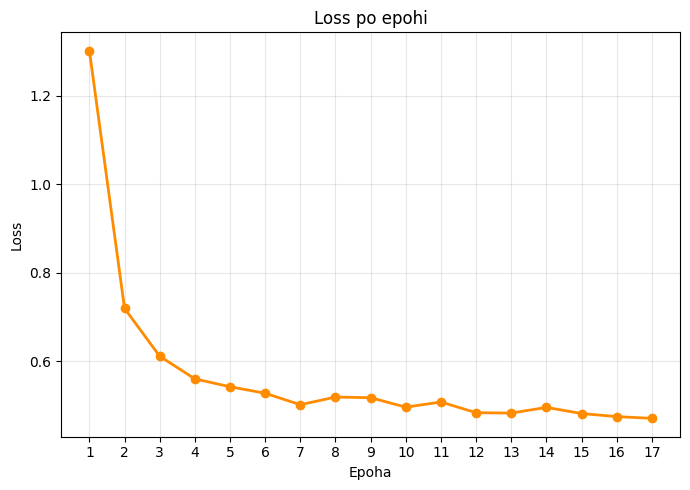

In [ ]:
set_seed(42)


BEST_LR = 4.54e-04
BEST_BATCH_SIZE = 256
BEST_EPOCHS = 17
BEST_WARMUP_R = 0.092
BEST_WD = 0.12
doc_to_chunks = {}
for chunk_id in chunked_corpus:
    doc_id = chunk_id.split("#")[0]
    if doc_id not in doc_to_chunks:
        doc_to_chunks[doc_id] = {}
    doc_to_chunks[doc_id][chunk_id] = 1

all_pairs = []
for qid, docs in qrels_train_final.items():
    for doc_id, score in docs.items():
        if score == 1:
            all_pairs.append({"query": queries_train_final[qid], "doc_id": doc_id})

for qid, docs in qrels_val.items():
    for doc_id, score in docs.items():
        if score == 1:
            all_pairs.append({"query": queries_val[qid], "doc_id": doc_id})

train_examples = []
for p in all_pairs:
    if p["doc_id"] in doc_to_chunks:
        for chunk_id in doc_to_chunks[p["doc_id"]]:
            train_examples.append(
                InputExample(texts=[p["query"], chunked_corpus[chunk_id]["text"]])
            )




device = "cuda" if torch.cuda.is_available() else "cpu"
base_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)
final_model = copy.deepcopy(base_model).to(device)

g = torch.Generator()
g.manual_seed(42)
dataloader = DataLoader(train_examples, shuffle=True, batch_size=BEST_BATCH_SIZE, generator=g)
steps_per_epoch = len(dataloader)



loss_values = []

class TrackedLoss(torch.nn.Module):
    def __init__(self, base_loss):
        super().__init__()
        self.base_loss = base_loss

    def forward(self, sentence_features, labels):
        loss = self.base_loss(sentence_features, labels)
        loss_values.append(loss.item())
        return loss

base_loss_fn = losses.MultipleNegativesRankingLoss(final_model)
tracked_loss = TrackedLoss(base_loss_fn)
warmup_steps = int(steps_per_epoch * BEST_EPOCHS * BEST_WARMUP_R)


final_model.fit(
    train_objectives=[(dataloader, tracked_loss)],
    epochs=BEST_EPOCHS,
    warmup_steps=warmup_steps,
    optimizer_params={"lr": BEST_LR},
    weight_decay=BEST_WD,
    show_progress_bar=True,
    output_path="finetuned_minilm_chunked"
)

final_model.save(FINETUNED_MODEL_DIR)

epoch_losses = [
    sum(loss_values[i * steps_per_epoch:(i + 1) * steps_per_epoch]) / steps_per_epoch
    for i in range(BEST_EPOCHS)
]


fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(range(1, BEST_EPOCHS + 1), epoch_losses, marker='o', color='darkorange', linewidth=2)
ax.set_xlabel("Epoha")
ax.set_ylabel("Loss")
ax.set_title("Loss po epohi")
ax.set_xticks(range(1, BEST_EPOCHS + 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(LOSS_PLOT_PATH, dpi=300, bbox_inches='tight')
plt.show()

## 7.1 Evaluacija fine-tuneovanog modela
Performanse su procenjene na nezavisnom test skupu.


U poređenju sa ranije dobijenim rezultatima, jasan je napredak kroz sve tri varijante modela.


Glavni doprinos dolazi od fine-tuninga, gde NDCG raste sa 0.6718 na 0.7818, Recall sa 0.8206 na 0.8840, a MRR sa 0.6260 na 0.7520.


In [ ]:
chunk_ids_list = list(chunked_corpus.keys())
chunk_texts = [chunked_corpus[cid]["text"] for cid in chunk_ids_list]

chunk_embeddings = final_model.encode(
    chunk_texts, convert_to_numpy=True, show_progress_bar=True
).astype("float32")

faiss.normalize_L2(chunk_embeddings)
index_ft = faiss.IndexFlatIP(chunk_embeddings.shape[1])
index_ft.add(chunk_embeddings)
id_map_ft = {i: cid for i, cid in enumerate(chunk_ids_list)}

k = 10
query_ids = list(queries_test.keys())
query_texts_test = [queries_test[qid] for qid in query_ids]

query_embeddings = final_model.encode(
    query_texts_test, convert_to_numpy=True, show_progress_bar=True
).astype("float32")

faiss.normalize_L2(query_embeddings)
distances, indices = index_ft.search(query_embeddings, k * 4)

results_ft = {}
for i, qid in enumerate(query_ids):
    results_ft[qid] = {}
    for rank, idx in enumerate(indices[i]):
        chunk_id = id_map_ft[idx]
        doc_id = chunk_id.split("#")[0]
        score = float(distances[i][rank])
        if doc_id not in results_ft[qid] or score > results_ft[qid][doc_id]:
            results_ft[qid][doc_id] = score
    results_ft[qid] = dict(
        sorted(results_ft[qid].items(), key=lambda x: x[1], reverse=True)[:k]
    )

ndcg_ft, _, recall_ft, _ = EvaluateRetrieval.evaluate(qrels_test, results_ft, [10])
mrr_ft = EvaluateRetrieval.evaluate_custom(qrels_test, results_ft, [10], metric="mrr")


print(f"NDCG@10:   {ndcg_ft['NDCG@10']:.4f}")
print(f"Recall@10: {recall_ft['Recall@10']:.4f}")
print(f"MRR@10:    {mrr_ft['MRR@10']:.4f}")

Batches:   0%|          | 0/477 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

NDCG@10:   0.7818
Recall@10: 0.8840
MRR@10:    0.7520


# 8. Ponovna izgradnja FAISS indeksa sa fine-tunovanim modelom

Nakon postupka treniranja, izmenjene su težine modela, što znači da će i izlaz iz modela biti drugačiji u odnosu na izlaz iz pretreniranog modela.

Zato se vrši ponovna izgradnja FAISS indeksa, kako na upitima tako i na dokumentima.

In [ ]:
chunk_ids_list = list(chunked_corpus.keys())
chunk_texts = [chunked_corpus[cid]["text"] for cid in chunk_ids_list]

model = SentenceTransformer(FINETUNED_MODEL_DIR,
                            device="cuda" if torch.cuda.is_available() else "cpu")
chunk_embeddings = model.encode(chunk_texts, convert_to_numpy=True,
                                show_progress_bar=True).astype("float32")

dim = chunk_embeddings.shape[1]
faiss.normalize_L2(chunk_embeddings)
index = faiss.IndexFlatIP(dim)
index.add(chunk_embeddings)

id_map = {i: chunk_id for i, chunk_id in enumerate(chunk_ids_list)}

faiss.write_index(index, "faiss_index_ft.bin")
with open("id_map_ft.json", "w") as f:
    json.dump(id_map, f)

print("u indeksu:", index.ntotal, "vektora")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/477 [00:00<?, ?it/s]

u indeksu: 15261 vektora


# 9. RAG SISTEM

RAG sistem sastoji se od dve komponente:

1. retriever-a, koji pronalazi relevantne dokumente iz korpusa.

2.  generatora, koji na osnovu pronađenih dokumenata i upita generiše odgovor.

Postupak pretrage:

1. Za zadatu tvrdnju prvo se iz FAISS indeksa preuzima prvih k najsličnijih čankova.
2.	Dovučeni kontekst mora da upadne u limit modela. Taj limit podrazumeva: ceo prompt (instrukcija, dokazi i tvrdnja). Kontekst se ne može slati neograničeno, već se računa raspoloživi budžet. Budžet se dobija tako što se od ukupnog limita oduzme broj tokena koji zauzima sam šablon prompta sa praznim kontekstom (fiksni, nepromenljivi deo) i mala sigurnosna rezerva SAFETY = 8 tokena, koja štiti od odstupanja u tokenizaciji. Ostatak je broj tokena na raspolaganju za sadržaj dokumenata.
3.	Punjenje konteksta. Pronađeni delovi radova se dodaju u kontekst jedan po jedan, i to tako što se dodaje naslov rada i tekst dovučenog komada teksta.
4.	Podešavanja generisanja. Pri samom generisanju ulaz se dodatno osigurava skraćivanjem na maksimalan dozvoljen broj tokena. Koristi se beam search sa četiri grane (umesto da u svakom koraku bira najverovatniju reč, model paralelno prati četiri kandidat-niza i bira onaj sa najvećom ukupnom verovatnoćom). Ponavljanje istog niza od tri tokena je zabranjeno čime se sprečava da model upadne u petlju. Dužina izlaza ograničena je za dva zadatka, kraćim za klasifikaciju (gde se očekuje samo True ili False) i dužim za objašnjenje. Za objašnjenje se postavlja i minimalna dužina, da odgovor ne bude prekratak.


In [ ]:
MAX_INPUT = 512
SAFETY = 8


STATUS_TEMPLATE = """Is this claim true or false? Answer only True or False.

Evidence:
{context}

Claim: {claim}
Answer:"""
EXPLAIN_TEMPLATE = """The claim is {verdict}. Based on the evidence, write one sentence explaining why. Start with "This claim is {verdict} because".

Evidence:
{context}

Claim: {claim}
Sentence:"""

def retrieve_deduplicated(claim, k=10, top_n=5):
    query_emb = model.encode([claim], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(query_emb) #pretvaranje upita u vektor
    scores, indices = index.search(query_emb, k) #vraca k najslicnih cankova

    seen_docs = set()
    results = []
    for idx, score in zip(indices[0], scores[0]):
        chunk_id = id_map[idx]
        doc_id = chunk_id.split("#")[0] #vadi dokument
        if doc_id in seen_docs:
            continue #svaki doc samo jednom
        seen_docs.add(doc_id)
        results.append({
            "doc_id": doc_id,
            "chunk_id": chunk_id,
            "title": corpus[doc_id]["title"],
            "text": chunked_corpus[chunk_id]["text"],
            "score": float(score)
        })
        if len(results) == top_n:
            break
    return results

def context_budget(template, claim, verdict="False"):
    skeleton = template.format(context="", claim=claim, verdict=verdict)
    fixed = len(llm_tokenizer.encode(skeleton, add_special_tokens=True))
    return MAX_INPUT - fixed - SAFETY

def build_context(docs, budget):
    parts = []
    used = 0
    for d in docs:
        block = f"Title: {d['title']}\n{d['text']}"
        toks = llm_tokenizer.encode(block, add_special_tokens=False)
        sep = 2 if parts else 0

        if used + sep + len(toks) <= budget:
            parts.append(block)
            used += sep + len(toks)
        else:
            remaining = budget - used - sep
            if remaining < 20:
                break
            parts.append(llm_tokenizer.decode(toks[:remaining]))
            break
    return "\n\n".join(parts), len(parts)

def run_prompt(prompt, max_new_tokens, min_new_tokens=0):
    inputs = llm_tokenizer(prompt, return_tensors="pt", max_length=MAX_INPUT, truncation=True)
    inputs = {key: v.to(llm_model.device) for key, v in inputs.items()}
    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        min_new_tokens=min_new_tokens,
        num_beams=4,
        do_sample=False,
        no_repeat_ngram_size=3
    )
    return llm_tokenizer.decode(outputs[0], skip_special_tokens=True)


def parse_status(text):
    t = text.lower()
    i_true = t.find("true")
    i_false = t.find("false")
    if i_true == -1 and i_false == -1:
        return "Unknown"
    if i_false == -1 or (i_true != -1 and i_true < i_false):
        return "True"
    return "False"

def generate_answer(claim, k=10, max_docs=5):
    docs = retrieve_deduplicated(claim, k=k, top_n=max_docs)

    #status template nema verdict explain ga ima uzima manji budzet da kontekst stane u oba
    budget = min(context_budget(STATUS_TEMPLATE, claim),
                 context_budget(EXPLAIN_TEMPLATE, claim))
    context, used_docs = build_context(docs, budget)

    #prvo presuda
    status_raw = run_prompt(STATUS_TEMPLATE.format(context=context, claim=claim), 5)
    status = parse_status(status_raw)

    #presudu proslediti u objasnjenje da model ne bira sam
    verdict = status.lower()
    explanation = run_prompt(
        EXPLAIN_TEMPLATE.format(context=context, claim=claim, verdict=verdict),
        60, min_new_tokens=20
    )

    source_lines = "\n".join([f"  [{i+1}] {d['title']}" for i, d in enumerate(docs[:used_docs])])
    answer = f"{explanation}\nSources:\n{source_lines}\nStatus: {status}"
    return {"answer": answer, "used_docs": used_docs, "budget": budget}

## 9.1. Gold Tvrdnje

U SciFact datasetu, gold tvrdnje su tvrdnje označene pouzdanom labelom istinitosti na osnovu dokaza iz relevantnih naučnih radova.

Svaka tvrdnja je klasifikovana kao tačna (True) ako je dokazi potvrđuju, netačna (False) ako je opovrgavaju, ili nepoznata (Unknown) ako odgovarajući dokazi ne postoje.

Te labele predstavljaju ground-truth referencu. Ovde služe da se porede dva opisana pristupa.

In [ ]:
url = "https://scifact.s3-us-west-2.amazonaws.com/release/latest/data.tar.gz"
urllib.request.urlretrieve(url, "scifact.tar.gz")
with tarfile.open("scifact.tar.gz") as t:
    t.extractall(".")
print(os.listdir("data"))

claim_label = {}
with open("data/claims_dev.jsonl") as f:
    for line in f:
        obj = json.loads(line)
        ev = obj.get("evidence", {})
        if not ev:
            label = "Unknown"
        else:
            first = next(iter(ev.values()))
            label = "True" if first[0]["label"] == "SUPPORT" else "False"
        claim_label[str(obj["id"])] = {"claim": obj["claim"], "label": label}

['claims_dev.jsonl', 'corpus.jsonl', 'claims_train.jsonl', 'cross_validation', 'claims_test.jsonl']


/tmp/ipykernel_25337/2959053194.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(".")


## 9.2 Poređenje pristupa

Prva varijanta je čist FLAN-T5-XL, bez retrieval komponente. Modelu se prosleđuje  prompt šablon, ali bez dela sa dokazima, tako da je jedina razlika prisustvo odnosno odsustvo konteksta, a ne formulacija zadatka. Odgovor se oslanja na znanje stečeno tokom predtreniranja, pa ova varijanta služi kao referentna vrednost koja pokazuje koliko model zna sam po sebi, bez pristupa spoljnim dokumentima.


Za drugu varijantu prikazan je sistem sa retrieverom (konkretno fine-tunovanim all-MiniLM-L6-v2). Poređenjem sa čistim modelom vidi se doprinos same retrieval komponente, odnosno koliko ubacivanje relevantnih dokumenata menja kvalitet i pouzdanost odgovora u odnosu na model prepušten sopstvenom znanju. Suštinski, baseline i fine tunovani model bi dali odgovor iste strukture, s tim da bi fine-tunovani model mogao bolje da pronađe relevantne dokumente (sudeći po test metrikama), pa je ovde prikazan slučaj njegovog korišćenja.
Prosleđena je ista tvrdnja za oba slučaja, preuzeta iz test upita:


In [ ]:
def status_no_context(claim):
    prompt = STATUS_TEMPLATE.format(context="(no evidence provided)", claim=claim)
    raw = run_prompt(prompt, 5)
    return parse_status(raw)

In [ ]:
qid = "113"
claim = claim_label[qid]["claim"]
gold = claim_label[qid]["label"]

#sam flant5 status i objasnjenje, bez konteksta
bare_status = status_no_context(claim)
bare_expl = run_prompt(
    EXPLAIN_TEMPLATE.format(context="(no evidence provided)", claim=claim, verdict=bare_status.lower()),
    60, min_new_tokens=20
)

#RAG
res = generate_answer(claim)

print("Claim:", claim)
print("Gold:", gold)
print()
print("FLAN-T5 bez konteksta")
print("Status:", bare_status)
print("Objasnjenje:", bare_expl)
print()
print(" FLAN-T5 + retriever")
print(res["answer"])

Claim: Angiotensin converting enzyme inhibitors are associated with increased risk for functional renal insufficiency.
Gold: True

FLAN-T5 bez konteksta
Status: False
Objasnjenje: This claim is false because Angiotensin converting enzyme inhibitors are not associated with increased risk for functional renal insufficiency.

 FLAN-T5 + retriever
This claim is true because angiotensin converting enzyme inhibitors are associated with increased risk for functional renal insufficiency.
Sources:
  [1] Renal considerations in angiotensin converting enzyme inhibitor therapy: a statement for healthcare professionals from the Council on the Kidney in Cardiovascular Disease and the Council for High Blood Pressure Research of the American Heart Association.
  [2] Differences in the Clinical Effects of Angiotensin-Converting Enzyme Inhibitors and Angiotensin Receptor Blockers: A Critical Review of the Evidence
Status: True
